# Assignment 1: PyTorch Introduction

In this assignment, you will start off by constructing a neural networks from scratch to get a stronger understanding of what is required to make neural networks work. Then in the second part of the assignment you will train a neural network (using PyTorch) to classify an image into one of two classes: "car" or "truck". The code for the neural networks
you train will be written for you, and you are not (yet!) expected
to understand all provided code. However, by the end of the assignment,
you should be able to:

1. Understand at a high level the training loop for a machine learning model.
2. Understand the distinction between training, validation, and test data.
3. The concepts of overfitting and underfitting.
4. Investigate how different hyperparameters, such as learning rate and batch size, affect the success of training.
5. Compare an ANN (aka Multi-Layer Perceptron) with a CNN.

*This assignment is based on an assignment developed by Prof. Lisa Zhang.*

### What to submit

Submit an HTML file containing all your code, outputs, and write-up
from parts A and B. Please take extra effort to make your answers and submissions readable. Do not display unnecessary outputs, only the ones that are important for supporting your answers.

You can produce a HTML file directly from Google Colab. The Colab instructions are provided at the end of this document.

**Do not submit any other files produced by your code.**

Include a link to your colab file in your submission.

Please use Google Colab to complete this assignment. If you want to use Jupyter Notebook, please complete the assignment and upload your Jupyter Notebook file to Google Colab for submission.

## Colab Link

Include a link to your colab file here and ensure the file can be accessed by the our teaching team.

Colab Link: https://colab.research.google.com/drive/1zBbOQJHbOtGjL5YT7whtmcQToaCy15Fr?usp=sharing

In [ ]:
# TO BE COMPLETED

https://colab.research.google.com/drive/1zBbOQJHbOtGjL5YT7whtmcQToaCy15Fr?usp=sharing

#PART A: Constructing a Neural Network [8pt]

Before we get into using PyTorch to train our classifier we will go through the process of creating our neural network from scratch. We've seen in the tutorial how to build a 1-layer network, now we'll take it one step further to build a 2-layer network. This is an important exercise that everyone should attempt at least once to understand and truly appreciate the workings of neural networks.

## Helper Functions

To help guide the construction we will use the iris dataset that was introduced in the tutorial. Provided are some helper code to get us started:

In [57]:
# load "Iris_3class.csv" to Google Colab
from google.colab import files
uploaded = files.upload()

In [1]:
import pandas as pd
import numpy as np

raw_data = pd.read_csv("Iris_3class.csv", header = None)
raw_data = raw_data.values
np.random.shuffle(raw_data)

In [2]:
import numpy as np

# split your data into training and validation
X_train = raw_data[0:100,:4]
y_train = raw_data[0:100,4:5].astype(int)
X_val = raw_data[100:,:4]
y_val = raw_data[100:,4:5].astype(int)

print(X_train.shape, y_train.shape)
print(X_train.dtype, y_train.dtype)
print(X_val.shape, y_val.shape)
print(X_val.dtype, y_val.dtype)

(100, 4) (100, 1)
float64 int64
(50, 4) (50, 1)
float64 int64


Recall that the neural network output consists of several nodes, one for each output class. Since the labels are provided as integers we will need to convert them into one-hot vectors to match the neural network output format.

In [3]:
#Convert array to one-hot encoding
def to_one_hot(Y):
    n_col = np.amax(Y) + 1
    binarized = np.zeros((len(Y), n_col))
    for i in range(len(Y)):
        binarized[i, Y[i]] = 1.
    return binarized

In [4]:
y_train = to_one_hot(y_train)
print(X_train.shape, y_train.shape)
print(X_train.dtype, y_train.dtype)

y_val = to_one_hot(y_val)
print(X_val.shape, y_val.shape)
print(X_val.dtype, y_val.dtype)

(100, 4) (100, 3)
float64 float64
(50, 4) (50, 3)
float64 float64


In [5]:
#verify one-hot encoding
y_train[0:5,:]

array([[0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.]])

## Part 1. Develop a 2-layer ANN [6pt MODEL]
At its core a 2-layer neural network is just a few lines of code. Most of the complexity comes from setting up the training of the network.

Using vectorized form, set up the neural network training to use a cross-entropy loss function and determine the gradients with resepect to the layer 1 and layer 2 weights.

In [6]:
# write code to create a 2-layer ANN in vectorized form

#define sigmoid
def sigmoid(x):
    return 1/(1+np.exp(-x))

#define softmax
def softmax(x):
  e = np.exp(x)
  return e/e.sum(axis=1, keepdims = True)


def ann(W, X_train, y_train):

  num_hidden = 5
  num_features = 4
  num_outputs = 3

  #Weights
  w0 = W[:20].reshape(num_features, num_hidden)
  w1 = W[20:].reshape(num_hidden, num_outputs)

  #Feed forward
  layer0 = X_train
  layer1 = sigmoid(np.dot(layer0, w0))
  layer2 = np.dot(layer1, w1)

  # softmax
  y_pred = softmax(layer2)

  #Back propagation using gradient descent

  #cross-entropy loss
  error = (-1/len(y_train))*np.sum(y_train * np.log(y_pred))# TO BE COMPLETED

  #initialize gradients to zero
  dw0 = np.zeros((num_features, num_hidden))# TO BE COMPLETED
  dw1 = np.zeros((num_hidden, num_outputs))# TO BE COMPLETED

  #calculate gradients
  dL_dlayer2 = y_pred - y_train
  dL_dlayer1 = np.dot(dL_dlayer2, w1.T)
  dlayer1_dlayer2 = layer1 * (1 - layer1)

  # TO BE COMPLETED

  #determine gradients
  dw1 += np.dot(layer1.T, dL_dlayer2)/len(y_train)# TO BE COMPLETED
  dw0 += np.dot(layer0.T, dL_dlayer1 * dlayer1_dlayer2)/len(y_train)# TO BE COMPLETED

  #combine gradients into one vector
  dW = np.array(list(dw0.flatten()) + list(dw1.flatten()))# TO BE COMPLETED

  return (error, dW, y_pred)


## Part 2. Train your neural network [2pt RESULT]
How well does your network work on the iris dataset?

In [7]:
num_hidden = 5
num_features = 4
num_outputs = 3

#initialize weights
w0 = 2*np.random.random((num_features, num_hidden)) - 1
w1 = 2*np.random.random((num_hidden, num_outputs)) - 1

#combine weights into a single vector
W = np.array(list(w0.flatten()) + list(w1.flatten()))

#train network
n = 0.001
iterations = 100000
errors = []
for i in range(iterations):
  (error, dW, y_pred) = ann(W, X_train, y_train)
  W += -dW * n
  errors.append(error)


In [8]:
#examine predictions on training data
(_, _, y_pred) = ann(W, X_train, y_train)
pred = np.round(y_pred, 0)
pred[:5]

array([[0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.]])

In [9]:
#examine ground truth training data
train = np.round(y_train, 0)
train[:5]

array([[0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.]])

In [10]:
accuracy= np.mean(train==pred)*100
print('The accuracy of our model is:', accuracy,'%')

The accuracy of our model is: 98.0 %


In [11]:
'''
PROVIDE YOUR ANSWER BELOW

The accuracy of our model on the Iris dataset is 98%. This shows that our model is able to correctly classify
98% of the time. This high accuracy indicates that our model is effective in distinguishing between the
different types of iris flowers in the dataset.

'''

'\nPROVIDE YOUR ANSWER BELOW\n\nThe accuracy of our model on the Iris dataset is 99.33%. This shows that our model is able to correctly classify\n99.33% of the time. This high accuracy indicates that our model is effective in distinguishing between the \ndifferent types of iris flowers in the dataset.\n\n'

## Part 3. Validation [2pt MODEL]
Validate that the gradients were computed correctly for the 2-layer neural network you developed.

In [12]:
#write code to numerical verify the gradients you calculated

num_hidden = 5
num_features = 4
num_outputs = 3

#initialize weights
w0 = 2*np.random.random((num_features, num_hidden)) - 1
w1 = 2*np.random.random((num_hidden, num_outputs)) - 1

#combine weights
W = np.array(list(w0.flatten()) + list(w1.flatten()))# TO BE COMPLETED

#compute gradients analytically
(error, dW, y_pred) = ann(W, X_train, y_train)

#compute gradients numerically
dW_num = np.zeros((len(W),1))

for ind in range(len(W)):
  #reset gradients
  We1 = np.array(list(w0.flatten()) + list(w1.flatten()))
  We2 = np.array(list(w0.flatten()) + list(w1.flatten()))

  #increment slightly
  We1[ind] = We1[ind] + 0.000001# TO BE COMPLETED
  We2[ind] = We2[ind] - 0.000001# TO BE COMPLETED

  #compute errors
  (error_e1, dW_e1, y_pred1) = ann(We1, X_train, y_train)
  (error_e2, dW_e2, y_pred2) = ann(We2, X_train, y_train)

  #obtain numerical gradients
  grad_num = (error_e1-error_e2)/0.000002# TO BE COMPLETED

  #display difference between numerical and analytic gradients
  print(round(abs(grad_num - dW[ind]), 4), grad_num, dW[ind])


0.0 -0.4143067375839138 -0.4143067374808534
0.0 -0.008670094420182295 -0.00867009443492562
0.0 -0.07014155067874839 -0.07014155060931132
0.0 -0.009684798518705406 -0.009684798686862858
0.0 -0.013144267119180597 -0.013144267133126733
0.0 -0.1855871138989329 -0.18558711390115465
0.0 -0.003920794022782559 -0.003920794002221231
0.0 -0.0547772488479481 -0.05477724884119341
0.0 -0.0014820121796432772 -0.001482012268444668
0.0 -0.02634284201885606 -0.02634284196504301
0.0 -0.33054351344929955 -0.33054351339296617
0.0 -0.00443628278556929 -0.0044362827125005635
0.0 -0.005393958057986481 -0.005393958070995842
0.0 -0.013137197663048994 -0.013137197634692495
0.0 0.03623354427606529 0.03623354434999339
0.0 -0.11129091648243161 -0.11129091642972443
0.0 -0.0005897435872981305 -0.0005897435814965898
0.0 0.0031666380628792012 0.003166638183998745
0.0 -0.004647420226433496 -0.004647420155461759
0.0 0.01757246814726443 0.01757246816112782
0.0 0.10701423169834356 0.10701423174009289
0.0 -0.01598924204149

# PART B: Cars vs Trucks [30Pt]

In the second part of the assignment we will see how we can use PyTorch to train a neural network to identify Cars and Trucks.

In [13]:
import numpy as np
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torch.utils.data.sampler import SubsetRandomSampler
import torchvision.transforms as transforms


## Part 0. Helper Functions

We will be making use of the following helper functions. You will be asked to look
at and possibly modify some of these, but you are not expected to understand all of them.

You should look at the function names and read the docstrings. If you are curious, come back and explore the code *after* making some progress on the lab.

In [14]:
###############################################################################
# Data Loading

def get_relevant_indices(dataset, classes, target_classes):
    """ Return the indices for datapoints in the dataset that belongs to the
    desired target classes, a subset of all possible classes.

    Args:
        dataset: Dataset object
        classes: A list of strings denoting the name of each class
        target_classes: A list of strings denoting the name of desired classes
                        Should be a subset of the 'classes'
    Returns:
        indices: list of indices that have labels corresponding to one of the
                 target classes
    """
    indices = []
    for i in range(len(dataset)):
        # Check if the label is in the target classes
        label_index = dataset[i][1] # ex: 9
        label_class = classes[label_index] # ex: 'truck'
        if label_class in target_classes:
            indices.append(i)
    return indices

def get_data_loader(target_classes, batch_size):
    """ Loads images of cars and trucks, splits the data into training, validation
    and testing datasets. Returns data loaders for the three preprocessed datasets.

    Args:
        target_classes: A list of strings denoting the name of the desired
                        classes. Should be a subset of the argument 'classes'
        batch_size: A int representing the number of samples per batch

    Returns:
        train_loader: iterable training dataset organized according to batch size
        val_loader: iterable validation dataset organized according to batch size
        test_loader: iterable testing dataset organized according to batch size
        classes: A list of strings denoting the name of each class
    """

    classes = ('plane', 'car', 'bird', 'cat',
               'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
    ########################################################################
    # The output of torchvision datasets are PILImage images of range [0, 1].
    # We transform them to Tensors of normalized range [-1, 1].
    transform = transforms.Compose(
        [transforms.ToTensor(),
         transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
    # Load CIFAR10 training data
    trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                            download=True, transform=transform)
    # Get the list of indices to sample from
    relevant_indices = get_relevant_indices(trainset, classes, target_classes)

    # Split into train and validation
    np.random.seed(1000) # Fixed numpy random seed for reproducible shuffling
    np.random.shuffle(relevant_indices)
    split = int(len(relevant_indices) * 0.8) #split at 80%

    # split into training and validation indices
    relevant_train_indices, relevant_val_indices = relevant_indices[:split], relevant_indices[split:]
    train_sampler = SubsetRandomSampler(relevant_train_indices)
    train_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                               num_workers=1, sampler=train_sampler)
    val_sampler = SubsetRandomSampler(relevant_val_indices)
    val_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                              num_workers=1, sampler=val_sampler)
    # Load CIFAR10 testing data
    testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                           download=True, transform=transform)
    # Get the list of indices to sample from
    relevant_test_indices = get_relevant_indices(testset, classes, target_classes)
    test_sampler = SubsetRandomSampler(relevant_test_indices)
    test_loader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                             num_workers=1, sampler=test_sampler)
    return train_loader, val_loader, test_loader, classes

###############################################################################
# Training
def get_model_name(name, batch_size, learning_rate, epoch):
    """ Generate a name for the model consisting of all the hyperparameter values

    Args:
        config: Configuration object containing the hyperparameters
    Returns:
        path: A string with the hyperparameter name and value concatenated
    """
    path = "model_{0}_bs{1}_lr{2}_epoch{3}".format(name,
                                                   batch_size,
                                                   learning_rate,
                                                   epoch)
    return path

def normalize_label(labels):
    """
    Given a tensor containing 2 possible values, normalize this to 0/1

    Args:
        labels: a 1D tensor containing two possible scalar values
    Returns:
        A tensor normalize to 0/1 value
    """
    max_val = torch.max(labels)
    min_val = torch.min(labels)
    norm_labels = (labels - min_val)/(max_val - min_val)
    return norm_labels

def evaluate(net, loader, criterion):
    """ Evaluate the network on the validation set.

     Args:
         net: PyTorch neural network object
         loader: PyTorch data loader for the validation set
         criterion: The loss function
     Returns:
         err: A scalar for the avg classification error over the validation set
         loss: A scalar for the average loss function over the validation set
     """
    total_loss = 0.0
    total_err = 0.0
    total_epoch = 0
    for i, data in enumerate(loader, 0):
        inputs, labels = data
        labels = normalize_label(labels)  # Convert labels to 0/1
        outputs = net(inputs)
        loss = criterion(outputs, labels.float())
        corr = (outputs > 0.0).squeeze().long() != labels
        total_err += int(corr.sum())
        total_loss += loss.item()
        total_epoch += len(labels)
    err = float(total_err) / total_epoch
    loss = float(total_loss) / (i + 1)
    return err, loss

###############################################################################
# Training Curve
def plot_training_curve(path):
    """ Plots the training curve for a model run, given the csv files
    containing the train/validation error/loss.

    Args:
        path: The base path of the csv files produced during training
    """
    import matplotlib.pyplot as plt
    train_err = np.loadtxt("{}_train_err.csv".format(path))
    val_err = np.loadtxt("{}_val_err.csv".format(path))
    train_loss = np.loadtxt("{}_train_loss.csv".format(path))
    val_loss = np.loadtxt("{}_val_loss.csv".format(path))
    plt.title("Train vs Validation Error")
    n = len(train_err) # number of epochs
    plt.plot(range(1,n+1), train_err, label="Train")
    plt.plot(range(1,n+1), val_err, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Error")
    plt.legend(loc='best')
    plt.show()
    plt.title("Train vs Validation Loss")
    plt.plot(range(1,n+1), train_loss, label="Train")
    plt.plot(range(1,n+1), val_loss, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(loc='best')
    plt.show()

## Part 1. Visualizing the Data

We will make use of some of the CIFAR-10 data set, which consists of
colour images of size 32x32 pixels belonging to 10 categories. You can
find out more about the dataset at https://www.cs.toronto.edu/~kriz/cifar.html

For this assignment, we will only be using the car and truck categories.
We have included code that automatically downloads the dataset the
first time that the main script is run.

In [15]:
# This will download the CIFAR-10 dataset to a folder called "data"
# the first time you run this code.
train_loader, val_loader, test_loader, classes = get_data_loader(
    target_classes=["car", "truck"],
    batch_size=1) # One image per batch

100%|██████████| 170498071/170498071 [00:02<00:00, 57318293.51it/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


### Part (i) [0.5pt EXPLORATORY]

Visualize some of the data by running the code below.
Include the visualization in your writeup.

(You don't need to submit anything else.)

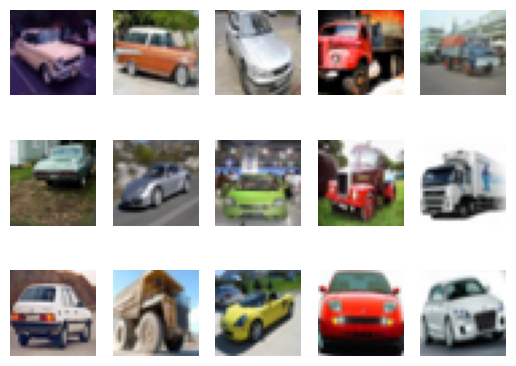

In [16]:
import matplotlib.pyplot as plt

k = 0
for images, labels in train_loader:
    # since batch_size = 1, there is only 1 image in `images`
    image = images[0]
    # place the colour channel at the end, instead of at the beginning
    img = np.transpose(image, [1,2,0])
    # normalize pixel intensity values to [0, 1]
    img = img / 2 + 0.5
    plt.subplot(3, 5, k+1)
    plt.axis('off')
    plt.imshow(img)

    k += 1
    if k > 14:
        break

In [17]:
'''
PROVIDE YOUR ANSWER BELOW

The obtained visualization for the cars and trucks classes are shown above.

'''

'\nPROVIDE YOUR ANSWER BELOW\n\nThe obtained visualization for the cars and trucks classes are shown above.\n\n'

### Part (ii) [1pt EXPLORATORY]

How many training examples do we have for the combined `car` and `truck` classes?
What about validation examples?
What about test examples?

In [18]:
print('The number of training examples are:', len(train_loader.dataset))
print('The number of validation examples are:', len(val_loader.dataset))
print('The number of test examples are:', len(test_loader.dataset))

The number of training examples are: 50000
The number of validation examples are: 50000
The number of test examples are: 10000


In [ ]:
'''
PROVIDE YOUR ANSWER BELOW

The number of training examples are: 50000
The number of validation examples are: 50000
The number of test examples are: 10000

'''

## Part 2. Training

We define two neural networks, a `LargeNet` and `SmallNet`.
We'll be training the networks in this section.

You won't understand fully what these networks are doing until
the next few classes, and that's okay. For this assignment, please
focus on learning how to train networks, and how hyperparameters affect
training.

In [20]:
class LargeNet(nn.Module):
    def __init__(self):
        super(LargeNet, self).__init__()
        self.name = "large"
        self.conv1 = nn.Conv2d(3, 5, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(5, 10, 5)
        self.fc1 = nn.Linear(10 * 5 * 5, 32)
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 10 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        x = x.squeeze(1) # Flatten to [batch_size]
        return x

In [21]:
class SmallNet(nn.Module):
    def __init__(self):
        super(SmallNet, self).__init__()
        self.name = "small"
        self.conv = nn.Conv2d(3, 5, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(5 * 7 * 7, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.conv(x)))
        x = self.pool(x)
        x = x.view(-1, 5 * 7 * 7)
        x = self.fc(x)
        x = x.squeeze(1) # Flatten to [batch_size]
        return x

In [22]:
small_net = SmallNet()
large_net = LargeNet()

### Part (i) [1pt EXPLORATORY]

The methods `small_net.parameters()` and `large_net.parameters()`
produces an iterator of all the trainable parameters of the network.
These parameters are torch tensors containing many scalar values.

We haven't learned how how the parameters in these high-dimensional
tensors will be used, but we should be able to count the number
of parameters. Measuring the number of parameters in a network is
one way of measuring the "size" of a network.

What is the total number of parameters in `small_net` and in
`large_net`? (Hint: how many numbers are in each tensor?)

In [23]:
for param in small_net.parameters():
    print(param.shape)

torch.Size([5, 3, 3, 3])
torch.Size([5])
torch.Size([1, 245])
torch.Size([1])


In [24]:
# TO BE COMPLETED
for param in large_net.parameters():
    print(param.shape)

torch.Size([5, 3, 5, 5])
torch.Size([5])
torch.Size([10, 5, 5, 5])
torch.Size([10])
torch.Size([32, 250])
torch.Size([32])
torch.Size([1, 32])
torch.Size([1])


In [25]:
smallnet_totalparameters = sum(p.numel() for p in small_net.parameters())
print("The Total Parameters in small_net is:", smallnet_totalparameters)

The Total Parameters in small_net is: 386


In [26]:
largenet_totalparameters = sum(p.numel() for p in large_net.parameters())
print("The Total Parameters in large_net is:", largenet_totalparameters)

The Total Parameters in large_net is: 9705


In [27]:
'''
PROVIDE YOUR ANSWER BELOW

Total number of parameters in smallnet is: 386
Explanation: (5*3*3*3) + 5 + 245 + 1 = 386

Total number of parameters in largenet is: 9705
Explanation: (5*3*5*5) + 5 + (10*5*5*5) + 10 + (32*250) + 32 + 32 + 1 = 9705

'''

'\nPROVIDE YOUR ANSWER BELOW\n\nTotal number of parameters in smallnet is: 386\nExplanation: (5*3*3*3) + 5 + 245 + 1 = 386\n\nTotal number of parameters in largenet is: 9705\nExplanation: (5*3*5*5) + 5 + (10*5*5*5) + 10 + (32*250) + 32 + 32 + 1 = 9705\n\n'

### The function train_net

The function `train_net` below takes an untrained neural network (like `small_net` and `large_net`) and
several other parameters. You should be able to understand how this function works.
The figure below shows the high level training loop for a machine learning model:

![alt text](https://github.com/UTNeural/Lab2/blob/master/Diagram.png?raw=true)

In [28]:
def train_net(net, batch_size=64, learning_rate=0.01, num_epochs=30):
    ########################################################################
    # Train a classifier on cars vs trucks
    target_classes = ["car", "truck"]
    ########################################################################
    # Fixed PyTorch random seed for reproducible result
    torch.manual_seed(1000)
    ########################################################################
    # Obtain the PyTorch data loader objects to load batches of the datasets
    train_loader, val_loader, test_loader, classes = get_data_loader(
            target_classes, batch_size)
    ########################################################################
    # Define the Loss function and optimizer
    # The loss function will be Binary Cross Entropy (BCE). In this case we
    # will use the BCEWithLogitsLoss which takes unnormalized output from
    # the neural network and scalar label.
    # Optimizer will be SGD with Momentum.
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.SGD(net.parameters(), lr=learning_rate, momentum=0.9)
    ########################################################################
    # Set up some numpy arrays to store the training/test loss/erruracy
    train_err = np.zeros(num_epochs)
    train_loss = np.zeros(num_epochs)
    val_err = np.zeros(num_epochs)
    val_loss = np.zeros(num_epochs)
    ########################################################################
    # Train the network
    # Loop over the data iterator and sample a new batch of training data
    # Get the output from the network, and optimize our loss function.
    start_time = time.time()
    for epoch in range(num_epochs):  # loop over the dataset multiple times
        total_train_loss = 0.0
        total_train_err = 0.0
        total_epoch = 0
        for i, data in enumerate(train_loader, 0):
            # Get the inputs
            inputs, labels = data
            labels = normalize_label(labels) # Convert labels to 0/1
            # Zero the parameter gradients
            optimizer.zero_grad()
            # Forward pass, backward pass, and optimize
            outputs = net(inputs)
            loss = criterion(outputs, labels.float())
            loss.backward()
            optimizer.step()
            # Calculate the statistics
            corr = (outputs > 0.0).squeeze().long() != labels
            total_train_err += int(corr.sum())
            total_train_loss += loss.item()
            total_epoch += len(labels)
        train_err[epoch] = float(total_train_err) / total_epoch
        train_loss[epoch] = float(total_train_loss) / (i+1)
        val_err[epoch], val_loss[epoch] = evaluate(net, val_loader, criterion)
        print(("Epoch {}: Train err: {}, Train loss: {} |"+
               "Validation err: {}, Validation loss: {}").format(
                   epoch + 1,
                   train_err[epoch],
                   train_loss[epoch],
                   val_err[epoch],
                   val_loss[epoch]))
        # Save the current model (checkpoint) to a file
        model_path = get_model_name(net.name, batch_size, learning_rate, epoch)
        torch.save(net.state_dict(), model_path)
    print('Finished Training')
    end_time = time.time()
    elapsed_time = end_time - start_time
    print("Total time elapsed: {:.2f} seconds".format(elapsed_time))
    # Write the train/test loss/err into CSV file for plotting later
    epochs = np.arange(1, num_epochs + 1)
    np.savetxt("{}_train_err.csv".format(model_path), train_err)
    np.savetxt("{}_train_loss.csv".format(model_path), train_loss)
    np.savetxt("{}_val_err.csv".format(model_path), val_err)
    np.savetxt("{}_val_loss.csv".format(model_path), val_loss)

### Part (ii) [0.5pt EXPLORATORY]

The parameters to the function `train_net` are hyperparameters of our neural network.
We made these hyperparameters easy to modify so that we can tune them later on.

What are the default values of the parameters `batch_size`, `learning_rate`,
and `num_epochs`?

In [29]:
'''
PROVIDE YOUR ANSWER BELOW

The default values of the parameters batch_size, learning_rate and num_epochs provided in the above code are: 64, 0.01, 30 respectively.

'''

'\nPROVIDE YOUR ANSWER BELOW\n\nThe default values of the parameters batch_size, learning_rate and num_epochs provided in the above code are: 64, 0.01, 30 respectively.\n\n'

### Part (iii) [0.5pt EXPLORATORY]
What files are written to disk when we call `train_net` with `small_net`, and train for 5 epochs? Provide a list
of all the files written to disk, and what information the files contain.

In [30]:
get_model_name(small_net.name, 64, 0.01, 1)

'model_small_bs64_lr0.01_epoch1'

In [31]:
'''
PROVIDE YOUR ANSWER BELOW

When we call train_net with small_net as the input with epochs=5, the following line of code writes the files to the disk:
      model_path = get_model_name(net.name, batch_size, learning_rate, epoch)
      torch.save(net.state_dict(), model_path)

The list of names of all files written are as follows:

  model_small_bs64_lr0.01_epoch0
  model_small_bs64_lr0.01_epoch1
  model_small_bs64_lr0.01_epoch2
  model_small_bs64_lr0.01_epoch3
  model_small_bs64_lr0.01_epoch4

These files contain the current state of the model's parameters, the weights and biases, for each epoch.
The keys in this dictionary are the names of the layers or parameters, and the values are the corresponding tensors representing the weights and biases.

Following the completion of training, the training error, training loss, validation error and validation loss are saved in 4 separate csv files.
The names of the files for the above mentioned parameters is as follows:

model_small_bs64_lr0.01_epoch4_train_err.csv
model_small_bs64_lr0.01_epoch4_train_loss.csv
model_small_bs64_lr0.01_epoch4_val_err.csv
model_small_bs64_lr0.01_epoch4_val_loss.csv

'''

"\nPROVIDE YOUR ANSWER BELOW\n\nWhen we call train_net with small_net as the input with epochs=5, the following line of code writes the files to the disk:\n      model_path = get_model_name(net.name, batch_size, learning_rate, epoch)\n      torch.save(net.state_dict(), model_path)\n\nThe list of names of all files written are as follows:\n\n  model_small_bs64_lr0.01_epoch0\n  model_small_bs64_lr0.01_epoch1\n  model_small_bs64_lr0.01_epoch2\n  model_small_bs64_lr0.01_epoch3\n  model_small_bs64_lr0.01_epoch4\n\nThese files contain the current state of the model's parameters, the weights and biases, for each epoch. \nThe keys in this dictionary are the names of the layers or parameters, and the values are the corresponding tensors representing the weights and biases.\n\nFollowing the completion of training, the training error, training loss, validation error and validation loss are saved in 4 separate csv files.\nThe names of the files for the above mentioned parameters is as follows:\n\n

### Part (iv) [0.5pt EXPLORATORY]
Train both `small_net` and `large_net` using the function `train_net` and its default parameters.
The function will write many files to disk, including a model checkpoint (saved values of model weights)
at the end of each epoch.

If you are using Google Colab, you will need to mount Google Drive
so that the files generated by `train_net` gets saved. We will be using
these files in the parts that follow.
(See the Google Colab tutorial for more information about this.)

Report the total time elapsed when training each network. Which network took longer to train?
Why?

In [32]:
# Since the function writes files to disk, you will need to mount
# your Google Drive. If you are working on the assignment locally, you
# can comment out this code.

from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [33]:
# TO BE COMPLETED
train_net(small_net)

Files already downloaded and verified
Files already downloaded and verified
Epoch 1: Train err: 0.382125, Train loss: 0.6400369286537171 |Validation err: 0.335, Validation loss: 0.6120706330984831
Epoch 2: Train err: 0.292875, Train loss: 0.5700971009731293 |Validation err: 0.267, Validation loss: 0.5393530651926994
Epoch 3: Train err: 0.230625, Train loss: 0.495483074426651 |Validation err: 0.2115, Validation loss: 0.4691940927878022
Epoch 4: Train err: 0.199625, Train loss: 0.44690241527557373 |Validation err: 0.1985, Validation loss: 0.4368020258843899
Epoch 5: Train err: 0.189625, Train loss: 0.4192982416152954 |Validation err: 0.192, Validation loss: 0.43094180431216955
Epoch 6: Train err: 0.18775, Train loss: 0.4135995798110962 |Validation err: 0.2125, Validation loss: 0.4505036808550358
Epoch 7: Train err: 0.18025, Train loss: 0.4003378431797028 |Validation err: 0.191, Validation loss: 0.41355117596685886
Epoch 8: Train err: 0.172625, Train loss: 0.39278369772434235 |Validation 

In [34]:
train_net(large_net)

Files already downloaded and verified
Files already downloaded and verified
Epoch 1: Train err: 0.44925, Train loss: 0.6910123801231385 |Validation err: 0.3865, Validation loss: 0.680934140458703
Epoch 2: Train err: 0.35675, Train loss: 0.637570574760437 |Validation err: 0.3385, Validation loss: 0.6168184895068407
Epoch 3: Train err: 0.279, Train loss: 0.5541795752048493 |Validation err: 0.238, Validation loss: 0.49576169438660145
Epoch 4: Train err: 0.215875, Train loss: 0.4731532244682312 |Validation err: 0.2025, Validation loss: 0.4500407828018069
Epoch 5: Train err: 0.195625, Train loss: 0.43613091158866885 |Validation err: 0.1845, Validation loss: 0.41856304090470076
Epoch 6: Train err: 0.18575, Train loss: 0.4128630776405334 |Validation err: 0.1745, Validation loss: 0.3952218536287546
Epoch 7: Train err: 0.15825, Train loss: 0.3655175129175186 |Validation err: 0.1585, Validation loss: 0.37735750060528517
Epoch 8: Train err: 0.1515, Train loss: 0.3499877415895462 |Validation err: 

In [36]:
'''
PROVIDE YOUR ANSWER BELOW

The total elapsed time for small_net is 141.16 seconds
The total elapsed time for large_net is 159.92 seconds

The large_net took the longer time to train as it has more parameters when compared to small_net and thus updating a
larger number of parameters requires more time and resources.

'''

'\nPROVIDE YOUR ANSWER BELOW\n\nThe total elapsed time for small_net is 141.16 seconds\nThe total elapsed time for large_net is 159.92 seconds\n\nThe large_net took the longer time to train as it has more parameters when compared to small_net and thus updating a \nlarger number of parameters requires more time and resources.\n\n'

### Part (v) [0.5pt EXPLORATORY]
Use the function `plot_training_curve` to display the trajectory of the
training/validation error and the training/validation loss.
You will need to use the function `get_model_name` to generate the
argument to the `plot_training_curve` function.

Do this for both the small network and the large network. Include both plots
in your writeup.

In [37]:
#model_path = get_model_name("small", batch_size=??, learning_rate=??, epoch=29)

In [38]:
# TO BE COMPLETED

model_path_smallnet = get_model_name("small", batch_size=64, learning_rate=0.01, epoch=29)
model_path_largenet = get_model_name("large", batch_size=64, learning_rate=0.01, epoch=29)

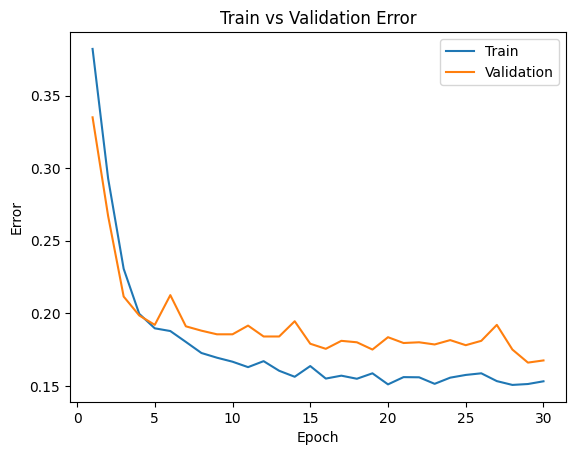

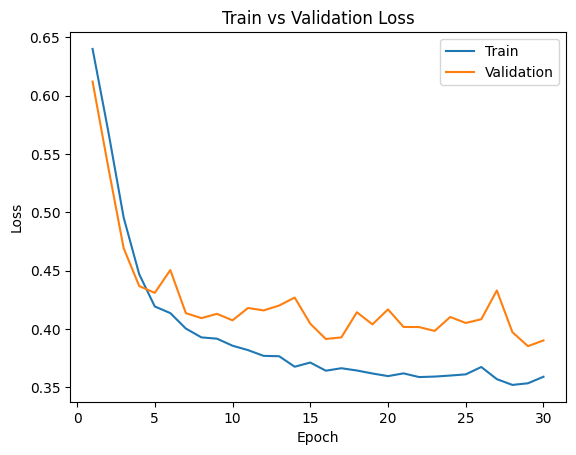

In [39]:
plot_training_curve(model_path_smallnet)

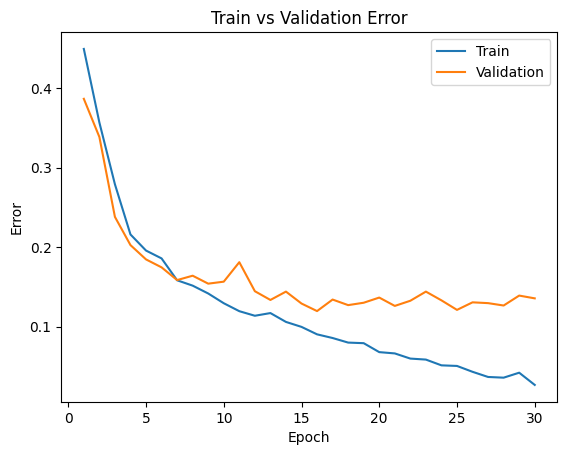

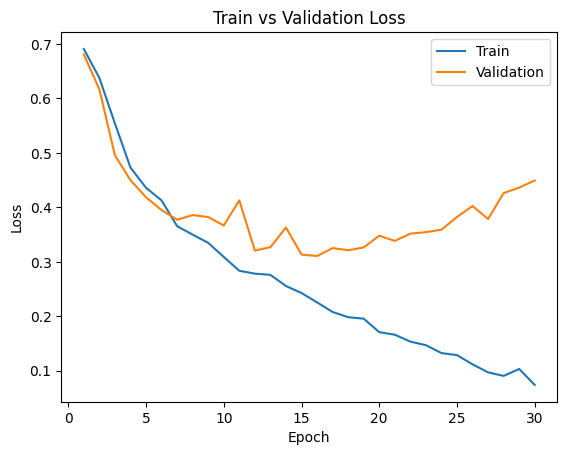

In [40]:
plot_training_curve(model_path_largenet)

In [41]:
'''
PROVIDE YOUR ANSWER BELOW

The path name which is a parameter to the plot_training_curve is generated using the get_model_name following which the plots for
trajectory of training/validation error and training/validation loss is plotted using the plot_training_curve function.


'''

'\nPROVIDE YOUR ANSWER BELOW\n\nThe path name which is a parameter to the plot_training_curve is generated using the get_model_name following which the plots for\ntrajectory of training/validation error and training/validation loss is plotted using the plot_training_curve function.\n\n\n'

### Part (vi) [0.5pt EXPLORATORY]
Describe what you notice about the training curve.
How do the curves differ for `small_net` and `large_net`?
Identify any occurences of underfitting and overfitting.

In [42]:
'''
PROVIDE YOUR ANSWER BELOW

From the graph, we can see that for SmallNet, the validation error and training error as well as the validation loss and training loss are almost similar in shape meaning
it appears to be a good fit.

In case of LargeNet, the validation loss starts to increase after epoch 18 when compared to training loss showing occurences of overfitting. It is overfitting as after epoch 18
we can see that the training loss continues to decrease however, the validation loss starts to increase showing that our model is not able to generalize to new data.


'''

'\nPROVIDE YOUR ANSWER BELOW\n\n\n\n\n\n\n'

## Part 3. Optimization Parameters

For this section, we will work with `large_net` only.

### Part (i) [0.5pt EXPLORATORY]
Train `large_net` with all default parameters, except set `learning_rate=0.001`.
Does the model take longer/shorter to train?
Plot the training curve. Describe the effect of *lowering* the learning rate.

In [57]:
# Note: When we re-construct the model, we start the training
# with *random weights*. If we omit this code, the values of
# the weights will still be the previously trained values.
large_net = LargeNet()

In [58]:
# TO BE COMPLETED
train_net(large_net, learning_rate=0.001)

Files already downloaded and verified
Files already downloaded and verified
Epoch 1: Train err: 0.4585, Train loss: 0.6922090911865234 |Validation err: 0.4145, Validation loss: 0.6918484680354595
Epoch 2: Train err: 0.404, Train loss: 0.6912762837409974 |Validation err: 0.401, Validation loss: 0.6909310147166252
Epoch 3: Train err: 0.39125, Train loss: 0.6897973504066467 |Validation err: 0.3825, Validation loss: 0.6891596242785454
Epoch 4: Train err: 0.391, Train loss: 0.6871493883132934 |Validation err: 0.379, Validation loss: 0.6860428061336279
Epoch 5: Train err: 0.37275, Train loss: 0.6819084930419922 |Validation err: 0.3725, Validation loss: 0.6794121749699116
Epoch 6: Train err: 0.367, Train loss: 0.6722611665725708 |Validation err: 0.3745, Validation loss: 0.6701584309339523
Epoch 7: Train err: 0.367375, Train loss: 0.6595345559120178 |Validation err: 0.3785, Validation loss: 0.6627401951700449
Epoch 8: Train err: 0.36425, Train loss: 0.6492524642944336 |Validation err: 0.3765, 

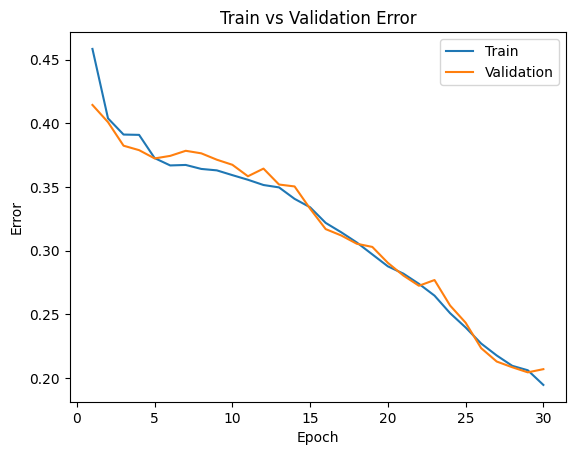

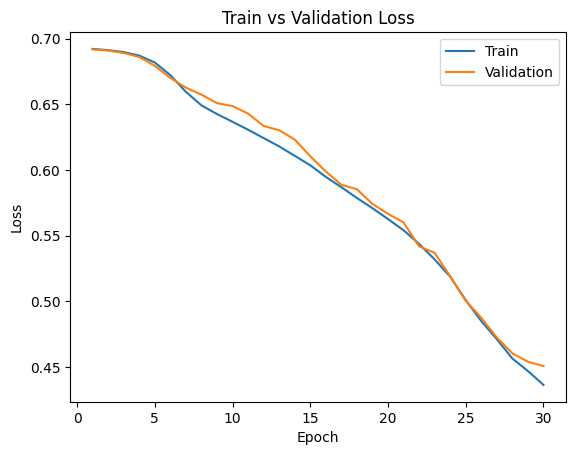

In [59]:
model_path_largenet_lr001 = get_model_name("large", batch_size=64, learning_rate=0.001, epoch=29)
plot_training_curve(model_path_largenet_lr001)

In [46]:
'''
PROVIDE YOUR ANSWER BELOW
Total time elapsed: 170.76 seconds
The training time for the model has increased than before. The reason for this can be attributed to smaller steps that is taken by the
model towards convergence. As a result, the gradient descent moves slowly towards the minima resulting in the additional time.

Lowering the learning rate produces the following observations: We can see the differences in graph from before where
now the training and validation loss curves seems to be similar indicating a good fit whereas before, after a certain epoch,
we could observe the overfitting nature of the model.

'''

'\nPROVIDE YOUR ANSWER BELOW\nTotal time elapsed: 164.67 seconds\nThe training time for the model has increased than before. The reason for this can be attributed to smaller steps that is taken by the\nmodel towards convergence. As a result, the gradient descent moves slowly towards the minima resulting in the additional time. \n\nLowering the learning rate produces the following observations: We can see the differences in graph from before where \nnow the training and validation loss curves seems to be similar indicating a good fit whereas before, after a certain epoch, \nwe could observe the overfitting nature of the model.\n\n'

### Part (ii) [0.5pt EXPLORATORY]
Train `large_net` with all default parameters, except set `learning_rate=0.1`.
Does the model take longer/shorter to train?
Plot the training curve. Describe the effect of *increasing* the learning rate.

In [56]:
# TO BE COMPLETED
large_net = LargeNet()
train_net(large_net, learning_rate=0.1)


Files already downloaded and verified
Files already downloaded and verified
Epoch 1: Train err: 0.3435, Train loss: 0.6152465670108795 |Validation err: 0.2655, Validation loss: 0.5401884317398071
Epoch 2: Train err: 0.26275, Train loss: 0.5457514839172364 |Validation err: 0.2255, Validation loss: 0.47185863088816404
Epoch 3: Train err: 0.205125, Train loss: 0.4577759726047516 |Validation err: 0.196, Validation loss: 0.42472241446375847
Epoch 4: Train err: 0.18375, Train loss: 0.42987853920459745 |Validation err: 0.193, Validation loss: 0.4498207103461027
Epoch 5: Train err: 0.182875, Train loss: 0.4176621789932251 |Validation err: 0.1765, Validation loss: 0.3949774377979338
Epoch 6: Train err: 0.1775, Train loss: 0.407295166015625 |Validation err: 0.218, Validation loss: 0.47349493484944105
Epoch 7: Train err: 0.15425, Train loss: 0.36420914459228515 |Validation err: 0.1665, Validation loss: 0.3992267334833741
Epoch 8: Train err: 0.143125, Train loss: 0.34258134818077085 |Validation er

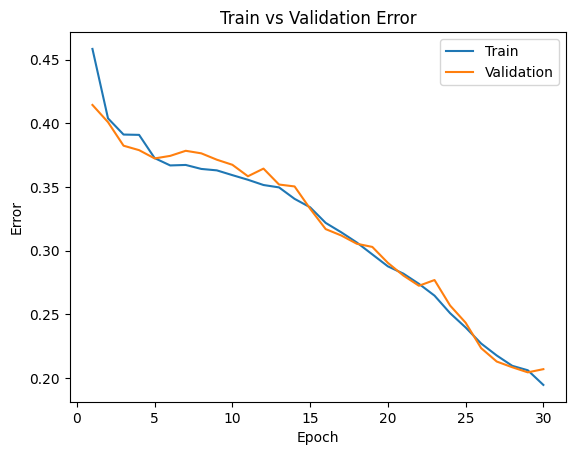

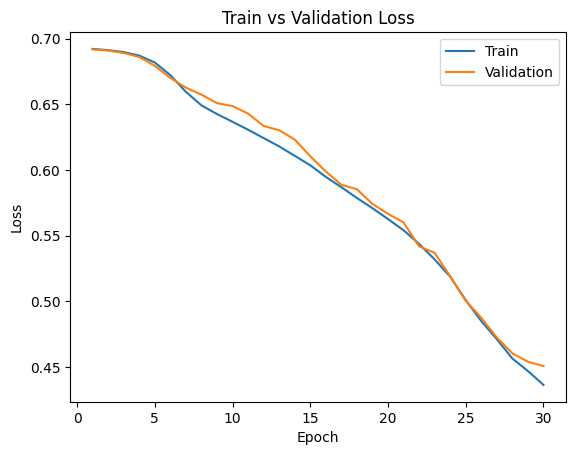

In [55]:
model_path_largenet_lr1 = get_model_name("large", batch_size=64, learning_rate=0.1, epoch=29)
plot_training_curve(model_path_largenet_lr001)

In [ ]:
'''
PROVIDE YOUR ANSWER BELOW

Total time elapsed: 170.20 seconds
The training time for the model decreased meagerly than before. The difference should have been more visible as the steps that we take in moving towards the optimum is bigger.
However, with a higher learning rate, there is a greater risk to overshoot the optimal weights.

The higher learning rate leads to a more erratic behavior in the curves than smooth curves which can be observed. That is the reason we can observe the error and loss starting
to increase earlier indicating that the model's weights have diverged from a good solution. A high learning rate can increase the risk of overfitting,
as the model may fit the training data more, capturing noise and thus it fails to generalize well to unseen data. Thus, increasing the learning rate here leads
to faster convergence but it increases the risk of instability and overfitting.


'''

### Part (iii) [0.5pt EXPLORATORY]

Train `large_net` with all default parameters, including with `learning_rate=0.01`.
Now, set `batch_size=512`. Does the model take longer/shorter to train?
Plot the training curve. Describe the effect of *increasing* the batch size.

In [50]:
# TO BE COMPLETED
large_net = LargeNet()
train_net(large_net, learning_rate=0.01, batch_size=512)


Files already downloaded and verified
Files already downloaded and verified
Epoch 1: Train err: 0.466, Train loss: 0.6923338621854782 |Validation err: 0.44, Validation loss: 0.6918952614068985
Epoch 2: Train err: 0.413, Train loss: 0.6914851702749729 |Validation err: 0.403, Validation loss: 0.6910877674818039
Epoch 3: Train err: 0.4035, Train loss: 0.6901152096688747 |Validation err: 0.3925, Validation loss: 0.6894860416650772
Epoch 4: Train err: 0.4, Train loss: 0.6876360848546028 |Validation err: 0.393, Validation loss: 0.686403214931488
Epoch 5: Train err: 0.373625, Train loss: 0.6824756488204002 |Validation err: 0.374, Validation loss: 0.6796957552433014
Epoch 6: Train err: 0.364375, Train loss: 0.6726636365056038 |Validation err: 0.3685, Validation loss: 0.6694183051586151
Epoch 7: Train err: 0.36475, Train loss: 0.6583152934908867 |Validation err: 0.3765, Validation loss: 0.659694567322731
Epoch 8: Train err: 0.365, Train loss: 0.6487302668392658 |Validation err: 0.38, Validation

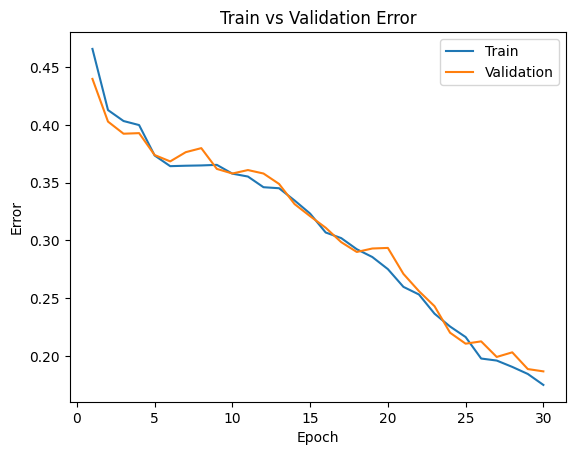

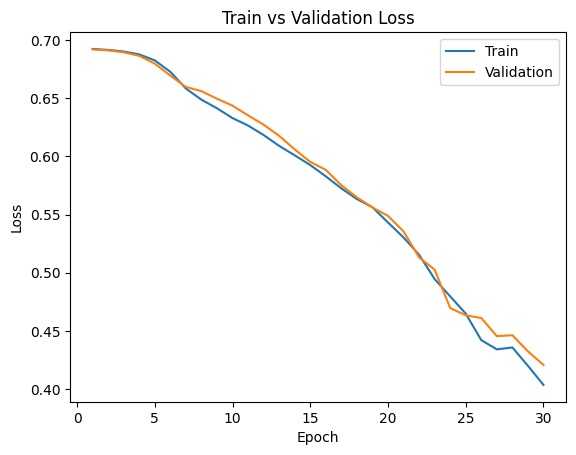

In [51]:
model_path_largenet_lr01_bs512 = get_model_name("large", batch_size=512, learning_rate=0.01, epoch=29)
plot_training_curve(model_path_largenet_lr01_bs512)

In [ ]:
'''
PROVIDE YOUR ANSWER BELOW

Total time elapsed: 152.15 seconds
We can see that the increase in the batch size has lead to faster training time. It is because now, the number of iterations in each epoch is less.

Moreover, we observe smoother training and validation loss curves as when the batch size is increased, we have lots of data in each batch which
helps in generalizing the data more. Thus, increasing the batch size here leads to faster training time, smoother curves showcasing a good fit and proper
generalization of data.


'''

### Part (iv) [0.5pt EXPLORATORY]

Train `large_net` with all default parameters, including with `learning_rate=0.01`.
Now, set `batch_size=16`. Does the model take longer/shorter to train?
Plot the training curve. Describe the effect of *decreasing* the batch size.

In [52]:
# TO BE COMPLETED

large_net = LargeNet()
train_net(large_net, learning_rate=0.01, batch_size=16)


Files already downloaded and verified
Files already downloaded and verified
Epoch 1: Train err: 0.34375, Train loss: 0.6175165125727653 |Validation err: 0.2625, Validation loss: 0.540454069852829
Epoch 2: Train err: 0.22325, Train loss: 0.4730004854500294 |Validation err: 0.2035, Validation loss: 0.43918069565296175
Epoch 3: Train err: 0.25525, Train loss: nan |Validation err: 0.4905, Validation loss: nan
Epoch 4: Train err: 0.502375, Train loss: nan |Validation err: 0.4905, Validation loss: nan
Epoch 5: Train err: 0.502375, Train loss: nan |Validation err: 0.4905, Validation loss: nan
Epoch 6: Train err: 0.502375, Train loss: nan |Validation err: 0.4905, Validation loss: nan
Epoch 7: Train err: 0.502375, Train loss: nan |Validation err: 0.4905, Validation loss: nan
Epoch 8: Train err: 0.502375, Train loss: nan |Validation err: 0.4905, Validation loss: nan
Epoch 9: Train err: 0.502375, Train loss: nan |Validation err: 0.4905, Validation loss: nan
Epoch 10: Train err: 0.502375, Train lo

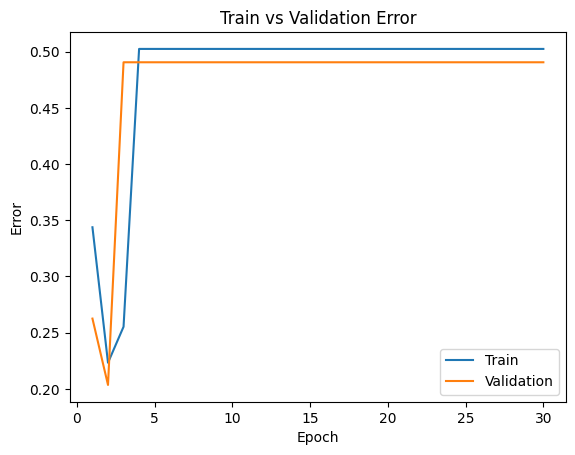

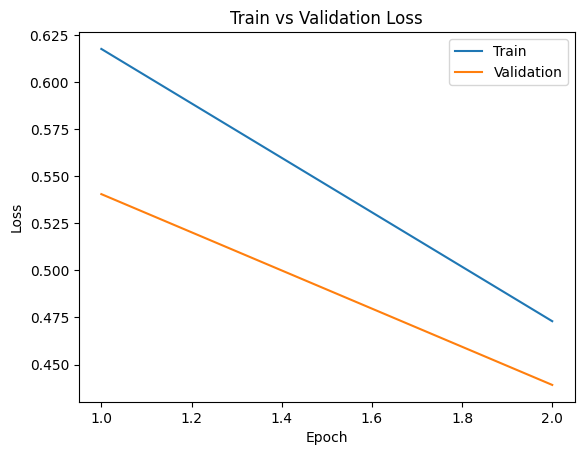

In [53]:
model_path_largenet_lr01_bs16 = get_model_name("large", batch_size=16, learning_rate=0.01, epoch=29)
plot_training_curve(model_path_largenet_lr01_bs16)

In [ ]:
'''
PROVIDE YOUR ANSWER BELOW

Total Elasped time: 232.92 seconds
We can see that decreasing the batch size to 16 has increased the training time. It is because each epoch will now require more iterations to process the entire dataset.
Smaller batch sizes lead to more weight updates per epoch as well.

Moreover, we can see the abnormal behaviour of the curves with small batch sizes. This small sizes causes more noise into the weight updates because we update it
based on a smaller sample of data. It also increases overfitting as the model fits the training data more closely. This ultimately results in
the model not generalizing to new data.

'''

## Part 4. Hyperparameter Search

### Part (i) [1pt EXPLORATORY]

Based on the plots from above, choose another set of values for the hyperparameters (network, batch_size, learning_rate)
that you think would help you improve the validation accuracy. Justify your choice.

In [ ]:
'''
PROVIDE YOUR ANSWER BELOW

I am choosing the hyperparameters that gave the best results from the graphs. Thus, the network chosen is LargeNet. The batch size chosen is 512 and the learning rate is 0.001.
This batch size helps in generalizing to new data more while at the same time increasing the training time since the number of iterations per epoch is less.
Choosing a small learning rate helps in not overshooting the optimal weights.


'''

### Part (ii) [0.5pt EXPLORATORY]

Train the model with the hyperparameters you chose in part(i), and include the training curve.

In [64]:
# TO BE COMPLETED

large_net = LargeNet()
train_net(large_net, learning_rate=0.001, batch_size=512)


Files already downloaded and verified
Files already downloaded and verified
Epoch 1: Train err: 0.485875, Train loss: 0.6924983970820904 |Validation err: 0.472, Validation loss: 0.692221611738205
Epoch 2: Train err: 0.478375, Train loss: 0.6923949047923088 |Validation err: 0.4695, Validation loss: 0.692174568772316
Epoch 3: Train err: 0.46825, Train loss: 0.6923299133777618 |Validation err: 0.459, Validation loss: 0.6920875608921051
Epoch 4: Train err: 0.4585, Train loss: 0.6922332793474197 |Validation err: 0.443, Validation loss: 0.6920361071825027
Epoch 5: Train err: 0.449375, Train loss: 0.6921333856880665 |Validation err: 0.441, Validation loss: 0.6919640898704529
Epoch 6: Train err: 0.438875, Train loss: 0.6920301467180252 |Validation err: 0.433, Validation loss: 0.6918835192918777
Epoch 7: Train err: 0.429875, Train loss: 0.6919135712087154 |Validation err: 0.421, Validation loss: 0.6918077170848846
Epoch 8: Train err: 0.42025, Train loss: 0.691812664270401 |Validation err: 0.406

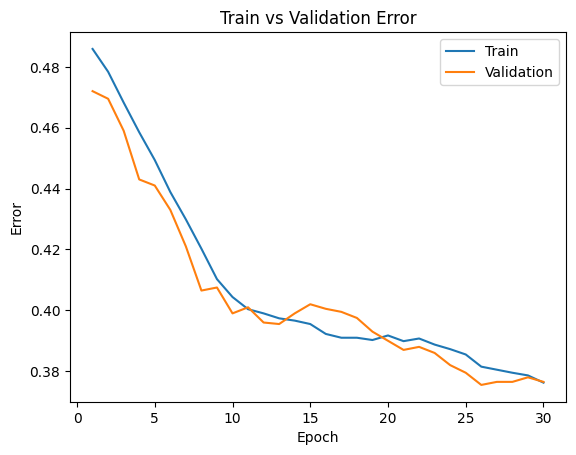

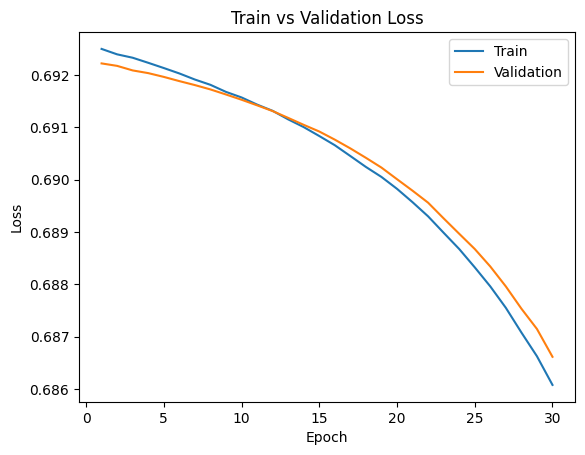

In [65]:
model_path_largenet_lr001_bs512 = get_model_name("large", batch_size=512, learning_rate=0.001, epoch=29)
plot_training_curve(model_path_largenet_lr001_bs512)

### Part (iii) [1pt EXPLORATORY]
Based on your result from Part(i), suggest another set of hyperparameter values to try.
Justify your choice.

In [66]:
'''
PROVIDE YOUR ANSWER BELOW

The results obtained from part (i) is good as the training time is also reasonable to other results and the training and validation errors as well as loss curves
seems to be good. I would like to explore how the same set of parameters would work on a different network and thus I am changing the network from Largenet to Smallnet.
The rest of the hyperparameters remains the same as before. Learning rate is 0.001 and batch size is 512.

'''

'\nPROVIDE YOUR ANSWER BELOW\n\nThe results obtained from part (i) is good as the training time is also reasonable to other results and the training and validation errors as well as loss curves \nseems to be good. I would like to explore how the same set of parameters would work on a different network and thus I am changing the network from Largenet to Smallnet. \nThe rest of the hyperparameters remains the same as before. Learning rate is 0.001 and batch size is 512.\n\n'

### Part (iv) [0.5pt EXPLORATORY]

Train the model with the hyperparameters you chose in part(iii), and include the training curve.

In [67]:
# TO BE COMPLETED

small_net = SmallNet()
train_net(small_net, learning_rate=0.001, batch_size=512)


Files already downloaded and verified
Files already downloaded and verified
Epoch 1: Train err: 0.500375, Train loss: 0.7022270038723946 |Validation err: 0.5095, Validation loss: 0.6983568072319031
Epoch 2: Train err: 0.48575, Train loss: 0.6934467926621437 |Validation err: 0.455, Validation loss: 0.6906303316354752
Epoch 3: Train err: 0.440625, Train loss: 0.6884354390203953 |Validation err: 0.421, Validation loss: 0.686109721660614
Epoch 4: Train err: 0.4165, Train loss: 0.6846117228269577 |Validation err: 0.3945, Validation loss: 0.6824286431074142
Epoch 5: Train err: 0.40175, Train loss: 0.680785097181797 |Validation err: 0.3845, Validation loss: 0.6785552501678467
Epoch 6: Train err: 0.385875, Train loss: 0.6771025881171227 |Validation err: 0.3715, Validation loss: 0.6752352714538574
Epoch 7: Train err: 0.375875, Train loss: 0.6732431165874004 |Validation err: 0.367, Validation loss: 0.671710655093193
Epoch 8: Train err: 0.368, Train loss: 0.6700139120221138 |Validation err: 0.362

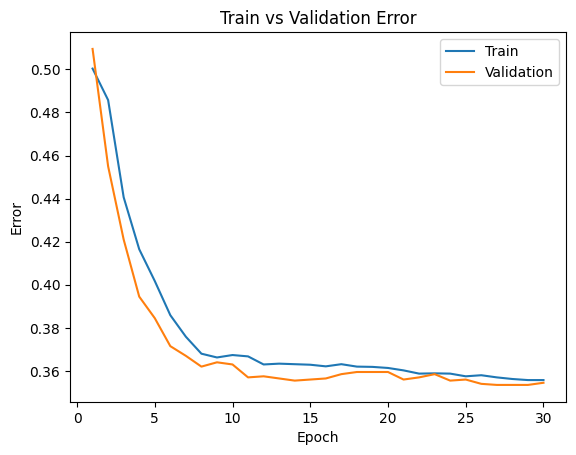

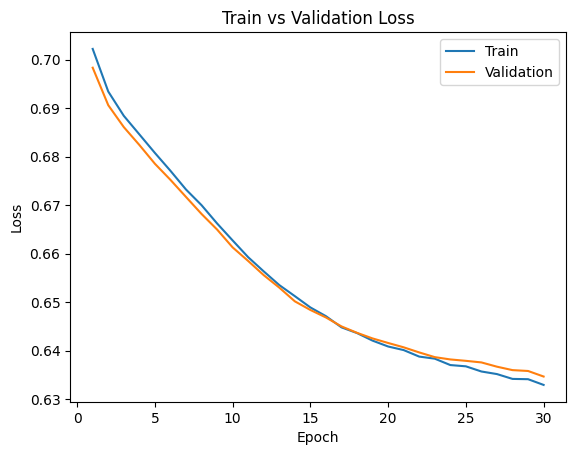

In [68]:
model_path_smallnet_lr001_bs512 = get_model_name("small", batch_size=512, learning_rate=0.001, epoch=29)
plot_training_curve(model_path_smallnet_lr001_bs512)

## Part 4. Evaluating the Best Model


### Part (i) [2pt MODEL]

Summarize in a table the results achieved on training and validation on all your model selections. This includes choice of `small_net` vs `large_net`, the `batch_size`, `learning_rate`,
**and the epoch number**. Hint: you can import the Pandas module to create tables.


Then upon reviewing the results choose your **best** model and load the model checkpoint. You can modify the code below to load your chosen set of weights to the model object `net`.

In [86]:
net = small_net
model_path = get_model_name(net.name, batch_size=64, learning_rate=0.01, epoch=10)
state = torch.load(model_path)
net.load_state_dict(state)

<All keys matched successfully>

In [90]:
# TO BE COMPLETED
import os
models = {'small', 'large'}
batch_size= {16, 64, 512}
learning_rates= {0.001, 0.01, 0.1}
epoch={29}
final_table=[]

for name in models:
  for b in batch_size:
    for lr in learning_rates:
      model_path= get_model_name (name, batch_size=b, learning_rate=lr, epoch=29)
      train_error_path="{}_train_err.csv".format(model_path)
      train_loss_path="{}_train_loss.csv".format(model_path)
      val_error_path="{}_val_err.csv".format(model_path)
      val_loss_path="{}_val_loss.csv". format(model_path)

      paths = [train_error_path, train_loss_path, val_error_path, val_loss_path]

      if all (os.path.exists(path) for path in paths):

        train_error, train_loss, val_error, val_loss= [np.loadtxt(path)[-1] for path in paths]

        final_table.append({"Model": name,
                        "batch size": b,
                        "learning rate": lr,
                        "Training Accuracy": (1- train_error)*100,
                        "Training Loss": train_loss *100,
                        "Validation Accuracy": (1- val_error)*100,
                        "Validation Loss":val_loss*100})

df= pd.DataFrame(final_table)
df


,Model,batch size,learning rate,Training Accuracy,Training Loss,Validation Accuracy,Validation Loss
0,large,16,0.010,49.7625,NaN,50.95,NaN
1,large,512,0.010,82.5250,40.353713,81.35,42.076249
2,large,512,0.001,62.3750,68.607920,62.35,68.661645
3,large,64,0.100,49.9125,69.375732,50.95,69.288491
4,large,64,0.010,97.3375,7.402446,86.45,44.943417
5,large,64,0.001,80.5375,43.634680,79.30,45.072489
6,small,512,0.001,64.4250,63.295422,64.55,63.468400
7,small,64,0.010,84.6875,35.905282,83.25,39.017701


### Part (ii) [4pt DISCUSSION]

Justify your choice of model from Part (i).

In [ ]:
'''
PROVIDE YOUR ANSWER BELOW

From the above table, we can see that for the combination of LargeNet as the network, Batch size as 64, Learning rate as 0.01 and epoch as 29 produces the best
validation accuracy and training accuracy while at the same time, the training loss and the validation loss are also minimal.


'''

### Part (iii) [4pt RESULT]

Using the helper code in Part 0, any code from lecture notes, or any code that you write, compute and report the **test classification error** for your chosen model.

In [91]:
# If you use the `evaluate` function provided in part 0, you will need to
# set batch_size > 1
train_loader, val_loader, test_loader, classes = get_data_loader(
    target_classes=["car", "truck"],
    batch_size=64)

Files already downloaded and verified
Files already downloaded and verified


In [92]:
# TO BE COMPLETED

test_error, test_loss = evaluate(net, test_loader, nn.BCEWithLogitsLoss())
print("Test classification error: {:.2f}%".format(test_error * 100))

Test classification error: 18.05%


### Part (iv) [3pt DISCUSSION]

How does the test classification error compare with the **validation error**?
Explain why you would expect the test error to be *higher* than the validation error.

In [93]:
validation_error, validation_loss = evaluate(net, val_loader, nn.BCEWithLogitsLoss())
print("Validation error: {:.2f}%".format(validation_error * 100))

Validation error: 19.15%


In [ ]:
'''
PROVIDE YOUR ANSWER BELOW

Test classification error:  18.05%
Validation error:  19.15%

The Validation error is infact a little bit higher than the test error. Generally, we expect the test error to be higher than the validation error as we make use of the
validation dataset in order to finetune our hyperparameters. However, test dataset is something completely new to the model. It is unseen by the model and thus we expect
the error for new dataset to be a higher than the validation error. From the above result, we can say that our model is in fact doing very good on unseen data
and is performing well.


'''

### Part (v) [3pt DISCUSSION]
Why did we only use the test data set at the very end?
Why is it important that we use the test data as little as possible?

In [ ]:
'''
PROVIDE YOUR ANSWER BELOW

We use the test data at the very end because we want to check how our model generalizes to new data. We can train the model as much as we want but unless it is
able to perform reasonably well on unseen data, it is of no use. Thus, we need to make sure that we use the test data as little as possible as we need to check the
perform the analysis on unseen data to approve its validity.


'''

## Part 5. Fully-Connected Linear ANN vs CNN [4pt RESULT]

Test out a 3-layer linear fully-connected ANN architecture (see simpleANN below). You should explore different hyperparameter settings to determine how well you can do on the validation dataset. Once satisified with the performance, you may test it out on the test data.

How does the your best CNN model compare with an 2-layer linear ANN model (no convolutional layers) on classifying car and truck images?

In [69]:
class simpleANN(nn.Module):
    def __init__(self):
        super(simpleANN, self).__init__()
        self.name = "simple"
        self.fc1 = nn.Linear(32*32*3, 100)
        self.fc2 = nn.Linear(100, 20)
        self.fc3 = nn.Linear(20, 1)

    def forward(self, x):
        x = x.view(-1, 32*32*3)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        x = x.squeeze(1) # Flatten to [batch_size]
        return x

In [70]:
# TO BE COMPLETED
linear_ann = simpleANN()
train_net(linear_ann)


Files already downloaded and verified
Files already downloaded and verified
Epoch 1: Train err: 0.3505, Train loss: 0.6190857963562012 |Validation err: 0.318, Validation loss: 0.6005008602514863
Epoch 2: Train err: 0.2715, Train loss: 0.5473552842140198 |Validation err: 0.2735, Validation loss: 0.5482391426339746
Epoch 3: Train err: 0.237875, Train loss: 0.49788166165351866 |Validation err: 0.2585, Validation loss: 0.5245580347254872
Epoch 4: Train err: 0.221125, Train loss: 0.468418163061142 |Validation err: 0.2705, Validation loss: 0.530538878403604
Epoch 5: Train err: 0.194125, Train loss: 0.4336024267673492 |Validation err: 0.2585, Validation loss: 0.5287860054522753
Epoch 6: Train err: 0.179875, Train loss: 0.40080515789985655 |Validation err: 0.25, Validation loss: 0.5345664564520121
Epoch 7: Train err: 0.163125, Train loss: 0.3704999762773514 |Validation err: 0.233, Validation loss: 0.54061468411237
Epoch 8: Train err: 0.137375, Train loss: 0.3308816604614258 |Validation err: 0.

In [74]:
linear_ann.name

'simple'

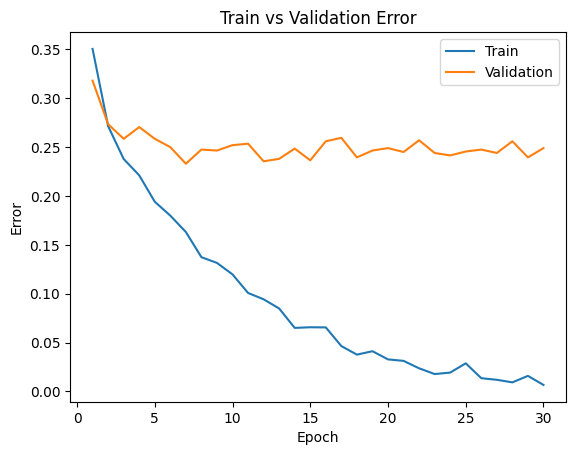

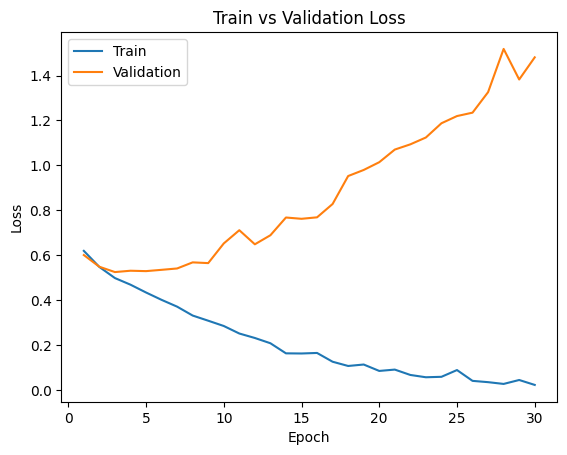

In [71]:
model_path_ann_lr01_bs64 = get_model_name('simple', batch_size=64, learning_rate=0.01, epoch=29)
plot_training_curve(model_path_ann_lr01_bs64)

In [72]:
linear_ann = simpleANN()
train_net(linear_ann, batch_size=512, learning_rate=0.01)


Files already downloaded and verified
Files already downloaded and verified
Epoch 1: Train err: 0.484875, Train loss: 0.6900144666433334 |Validation err: 0.4195, Validation loss: 0.6753106713294983
Epoch 2: Train err: 0.36675, Train loss: 0.6508757993578911 |Validation err: 0.3575, Validation loss: 0.6337455064058304
Epoch 3: Train err: 0.339375, Train loss: 0.6179464161396027 |Validation err: 0.338, Validation loss: 0.6138997226953506
Epoch 4: Train err: 0.322125, Train loss: 0.5996034294366837 |Validation err: 0.32, Validation loss: 0.6033456474542618
Epoch 5: Train err: 0.306875, Train loss: 0.5859731659293175 |Validation err: 0.3075, Validation loss: 0.5925673544406891
Epoch 6: Train err: 0.285375, Train loss: 0.5660174041986465 |Validation err: 0.3005, Validation loss: 0.5806102752685547
Epoch 7: Train err: 0.274, Train loss: 0.5499017760157585 |Validation err: 0.288, Validation loss: 0.5684104710817337
Epoch 8: Train err: 0.26375, Train loss: 0.535404447466135 |Validation err: 0.

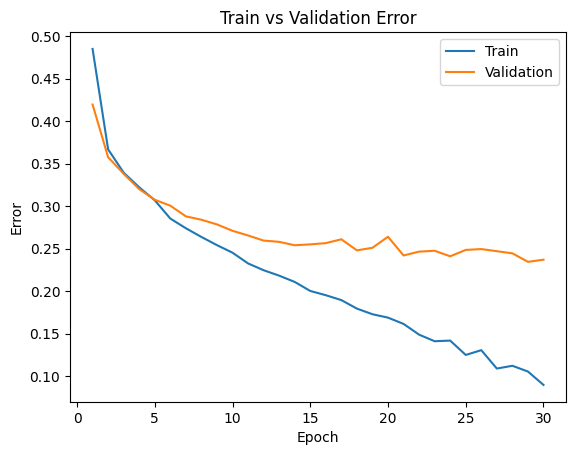

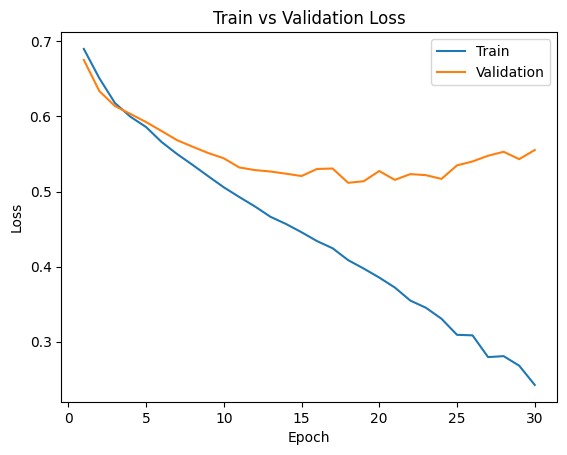

In [73]:
model_path_ann_lr01_bs512 = get_model_name('simple', batch_size=512, learning_rate=0.01, epoch=29)
plot_training_curve(model_path_ann_lr01_bs512)

In [75]:
linear_ann = simpleANN()
train_net(linear_ann, batch_size=64, learning_rate=0.001)

Files already downloaded and verified
Files already downloaded and verified
Epoch 1: Train err: 0.4565, Train loss: 0.681265832901001 |Validation err: 0.382, Validation loss: 0.6603339649736881
Epoch 2: Train err: 0.350375, Train loss: 0.6368848595619202 |Validation err: 0.352, Validation loss: 0.6284482646733522
Epoch 3: Train err: 0.327125, Train loss: 0.610190733909607 |Validation err: 0.3295, Validation loss: 0.6098903380334377
Epoch 4: Train err: 0.30925, Train loss: 0.5932393746376038 |Validation err: 0.312, Validation loss: 0.5974772218614817
Epoch 5: Train err: 0.296625, Train loss: 0.5775851504802704 |Validation err: 0.3075, Validation loss: 0.5878970678895712
Epoch 6: Train err: 0.281375, Train loss: 0.5625726225376129 |Validation err: 0.291, Validation loss: 0.576372548006475
Epoch 7: Train err: 0.27, Train loss: 0.5474849174022675 |Validation err: 0.289, Validation loss: 0.5695346472784877
Epoch 8: Train err: 0.260125, Train loss: 0.5336883389949798 |Validation err: 0.2775,

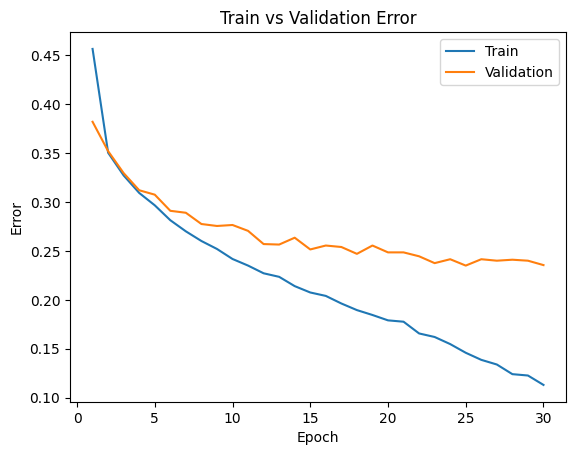

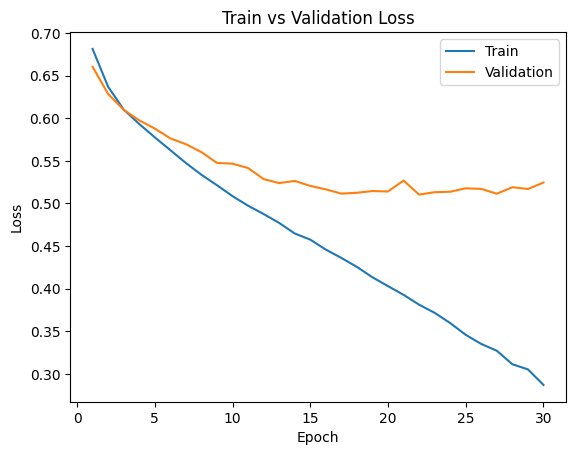

In [76]:
model_path_ann_lr001_bs64 = get_model_name('simple', batch_size=64, learning_rate=0.001, epoch=29)
plot_training_curve(model_path_ann_lr001_bs64)

In [99]:
linear_ann = simpleANN()
train_net(linear_ann, batch_size=512, learning_rate=0.001)

Files already downloaded and verified
Files already downloaded and verified
Epoch 1: Train err: 0.501875, Train loss: 0.6957913041114807 |Validation err: 0.493, Validation loss: 0.6898164302110672
Epoch 2: Train err: 0.493625, Train loss: 0.6858902350068092 |Validation err: 0.4655, Validation loss: 0.6811210215091705
Epoch 3: Train err: 0.422625, Train loss: 0.6774952374398708 |Validation err: 0.4025, Validation loss: 0.6738025844097137
Epoch 4: Train err: 0.384, Train loss: 0.6699676439166069 |Validation err: 0.3785, Validation loss: 0.6675718277692795
Epoch 5: Train err: 0.36525, Train loss: 0.6632999517023563 |Validation err: 0.3735, Validation loss: 0.6614619791507721
Epoch 6: Train err: 0.36, Train loss: 0.6568794548511505 |Validation err: 0.3745, Validation loss: 0.656317412853241
Epoch 7: Train err: 0.357, Train loss: 0.6509589292109013 |Validation err: 0.3665, Validation loss: 0.6515011340379715
Epoch 8: Train err: 0.356375, Train loss: 0.6458619758486748 |Validation err: 0.364

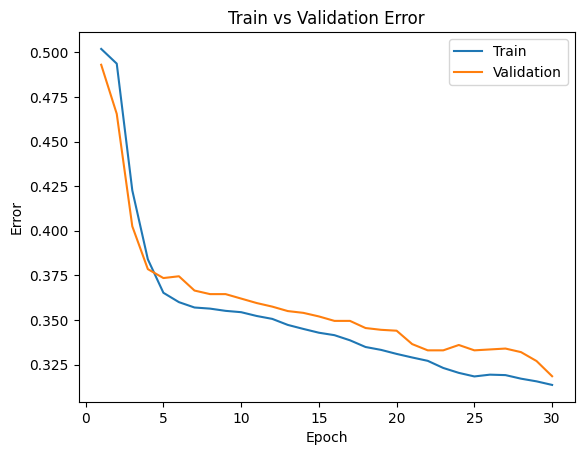

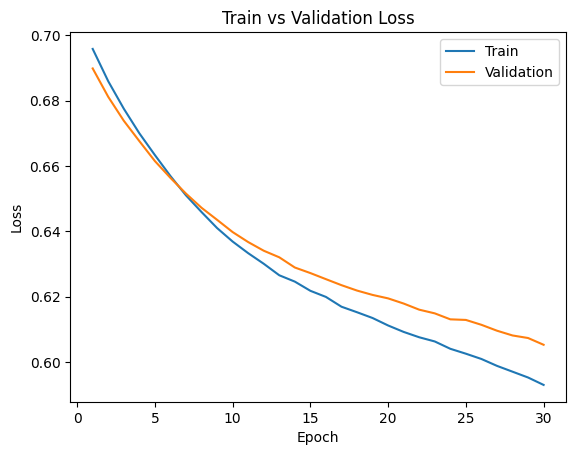

In [100]:
model_path_ann_lr001_bs512 = get_model_name('simple', batch_size=512, learning_rate=0.001, epoch=29)
plot_training_curve(model_path_ann_lr001_bs512)

In [ ]:
'''
PROVIDE YOUR ANSWER BELOW

The network chosen is simpleANN() with the best learning_rate: 0.001, batch_size: 512, epoch: 29

The model with these specific parameters performed the best on the validation data and training data.


'''

In [101]:
test_error, test_loss = evaluate(linear_ann, test_loader, nn.BCEWithLogitsLoss())
print("Test classification error: {:.2f}%".format(test_error * 100))

Test classification error: 31.90%


# PART C (Optional) - Bonus Challenge!

This is an optional exercise for those that finish the assignment early and would like to perform a deeper exploration of the assignment.

In part A we constructed and trained a 2-layer neural network from scratch. In Part B we saw how PyTorch can be used to simplify the construction of neural networks by taking care of all the complexity related to gradient calculations, training on GPUs, and structuring your code.

For this bonus challenge we will propose additional task that will have you work towards completing the pipeline and deploying the models online, while exploring ways to improve these models along the way.

Tasks:

1. Modify your code to classify images that are not cars or trucks into the category "other".
2. Preprocess images from the internet to be able to classify any images into cars and trucks (i.e., resize, aspect ratio, etc.). Evaluate your best model's performance on images loaded from the internet.
3. Deploy your best model onto huggingface spaces (or other web hosting services) to classify images into cars, trucks, and "other" if you've completed task 1.

Bonus marks will be provided based on the number of tasks completed and how well they are completed. Summarize below your results and anything intersting you learned from the steps that you completed. Bonus marks cannot be accumulated beyond a maximum assignment grade.

In [ ]:
# TO BE COMPLETED






In [ ]:
'''
PROVIDE YOUR ANSWER BELOW






'''

### Saving to HTML
Detailed instructions for saving to HTML can be found <a href="https://stackoverflow.com/questions/53460051/convert-ipynb-notebook-to-html-in-google-colab/64487858#64487858">here</a>. Provided below are a summary of the instructions:

(1) download your ipynb file by clicking on File->Download.ipynb

(2) reupload your file to the temporary Google Colab storage (you can access the temporary storage from the tab to the left)

(3) run the following:

In [ ]:
%%shell
jupyter nbconvert --to html A1_PyTorch_Introduction.ipynb

(4) the html file will be available for download in the temporary Google Colab storage

(5) review the html file and make sure all the results are visible before submitting your assignment to Quercus

# Assignment Grading Rubric
The grading of the assignment will be based on the following categories:

(1) **10 Pt - EXPLORATORY QUESTIONS** These are basic questions that in most cases can be answered without requiring a fully working and trained neural network model. For example, data loading, processing and visualization, summary statistics, data exploration, model and training setup, etc.

(2) **10 Pt - MODEL** Student has successfully implemented all the required neural network models and has demonstrated successful training of the model without any errors.

(3) **10 Pt - RESULT** Students are evaluated based on the results achieved in comparison to the expected results of the assignment.

(4) **10 Pt - DISCUSSION QUESTIONS** Student demonstrated understanding beyond the basic exploratory questions, can answer some of the more challenging questions, and provide arguments for their model selection decisions.

(5) **10 Pt - COMMUNICATION** Student has provided a quality submission that is easy to read without too many unnecessary output statements that distract the reading of the document. The code has been well commented and all the answers are communicated clearly and concisely.

(6) **10 Pt - BONUS** Student has completed the assignment and has taken on the challenging bonus tasks listed in PART C. The student has demonstrated a good understanding of all aspects of the assignment and has exceeded expectations for the assignment.



**TOTAL GRADE = _____ of 50 Pts**